In [1]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.linear_model import LinearRegression
warnings.simplefilter(action='ignore', category=FutureWarning)


#DATASET LOAD
df = pd.read_csv('GDP.csv')

#### 1 .Data Cleaning

In [2]:
df.head(10)

,Country,2020,2021,2022,2023,2024,2025
0,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN
1,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0
2,Algeria,164774,185850.0,225709.0,247789.0,264913.0,268885.0
3,Andorra,2885,3325.0,3376.0,3786.0,4038.0,4035.0
4,Angola,66521,84375.0,142442.0,109764.0,115946.0,113343.0
5,Antigua and Barbuda,1412,1602.0,1867.0,2006.0,2225.0,2373.0
6,Argentina,385218,486040.0,632318.0,645511.0,632145.0,683533.0
7,Armenia,12642,13879.0,19514.0,24086.0,25533.0,26258.0
8,Aruba,2486,2929.0,3279.0,3649.0,3952.0,4100.0
9,Australia,1362613,1655843.0,1725461.0,1742461.0,1796805.0,1771681.0


In [3]:
df.describe()

,2020,2021,2022,2023,2024,2025
count,1.960000e+02,1.940000e+02,1.940000e+02,1.940000e+02,1.920000e+02,1.890000e+02
mean,4.378886e+05,5.043504e+05,5.255064e+05,5.486173e+05,5.756871e+05,5.991414e+05
std,1.942936e+06,2.220864e+06,2.347886e+06,2.453040e+06,2.573189e+06,2.693421e+06
min,5.200000e+01,6.200000e+01,6.100000e+01,6.300000e+01,6.500000e+01,6.500000e+01
25%,9.588000e+03,1.114175e+04,1.265000e+04,1.360450e+04,1.350050e+04,1.421400e+04
50%,3.533450e+04,3.771900e+04,4.156800e+04,4.363100e+04,4.713550e+04,4.782900e+04
75%,2.074810e+05,2.546132e+05,2.746308e+05,2.850355e+05,2.915108e+05,3.032930e+05
max,2.135412e+07,2.368118e+07,2.600690e+07,2.772072e+07,2.918490e+07,3.050722e+07


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  196 non-null    object 
 1   2020     196 non-null    int64  
 2   2021     194 non-null    float64
 3   2022     194 non-null    float64
 4   2023     194 non-null    float64
 5   2024     192 non-null    float64
 6   2025     189 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 10.8+ KB


In [5]:
df.isnull().sum()

Country    0
2020       0
2021       2
2022       2
2023       2
2024       4
2025       7
dtype: int64

In [6]:
df.fillna(0 , inplace=True)

In [7]:
df.isnull().sum()

Country    0
2020       0
2021       0
2022       0
2023       0
2024       0
2025       0
dtype: int64

In [8]:
year_columns = ['2020',	'2021',	'2022',	'2023',	'2024',	'2025']
df[year_columns]=df[year_columns].astype(int)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Country  196 non-null    object
 1   2020     196 non-null    int64 
 2   2021     196 non-null    int64 
 3   2022     196 non-null    int64 
 4   2023     196 non-null    int64 
 5   2024     196 non-null    int64 
 6   2025     196 non-null    int64 
dtypes: int64(6), object(1)
memory usage: 10.8+ KB


In [10]:
df.head(5)

,Country,2020,2021,2022,2023,2024,2025
0,Afghanistan,20136,14278,14501,17248,0,0
1,Albania,15271,18086,19185,23388,27259,28372
2,Algeria,164774,185850,225709,247789,264913,268885
3,Andorra,2885,3325,3376,3786,4038,4035
4,Angola,66521,84375,142442,109764,115946,113343


In [11]:
df.duplicated().sum()

np.int64(0)

*NULL Values Replace with 0 , Float Datatype - Change with Int-DataType*

In [12]:
df.head()

,Country,2020,2021,2022,2023,2024,2025
0,Afghanistan,20136,14278,14501,17248,0,0
1,Albania,15271,18086,19185,23388,27259,28372
2,Algeria,164774,185850,225709,247789,264913,268885
3,Andorra,2885,3325,3376,3786,4038,4035
4,Angola,66521,84375,142442,109764,115946,113343


## 2. Trend Analysis

**Plot GDP growth for a specific country from 2020–2025**

Entry Specific Country Name India


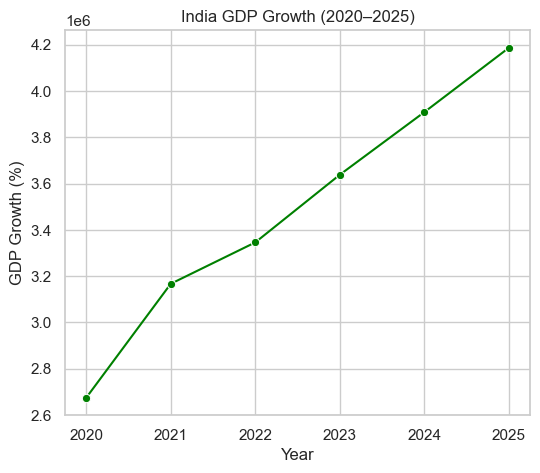

In [13]:
Country = input("Entry Specific Country Name")
Country_df = df[df['Country']== Country]

sns.set(style="whitegrid")
df_Melted = pd.melt(Country_df , id_vars=['Country'] , var_name='Year' , value_name='GDP_Growth')

plt.figure(figsize=(6,5))
sns.lineplot(x='Year', y='GDP_Growth', data=df_Melted, marker='o', color='green')
plt.title(f"{Country} GDP Growth (2020–2025)")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.show()

**Find the year with maximum GDP growth for each country.**

Enter the country name:  India


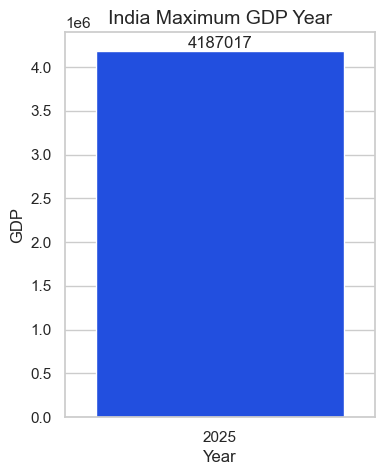

In [20]:
Country = input("Enter the country name: ")
Country_df = df[df['Country'] == Country]
df_melted = pd.melt(Country_df , id_vars=['Country'] , var_name='Year' , value_name='GDP')
max_row = df_melted.loc[df_melted['GDP'].idxmax()]
max_df = pd.DataFrame([max_row])


plt.figure(figsize=(4,5))
bar = sns.barplot(
    data=max_df,
    x="Year",
    y="GDP",
    palette="bright"
)


for p in bar.patches:
    bar.annotate(
        format(p.get_height(), '.0f'),
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center', va='bottom', fontsize=12
    )

plt.title(f"{Country} Maximum GDP Year", fontsize=14)
plt.xlabel("Year")
plt.ylabel("GDP")
plt.show()


## 3. Comparative Analysis

**Find the top 3 countries with the highest GDP in 2025.**

Entry How many you want to see 2


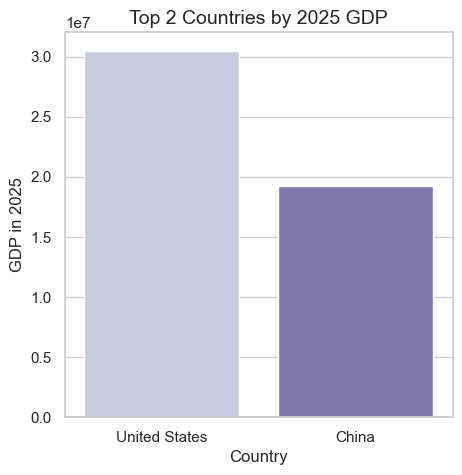

In [15]:
Country = int(input("Entry How many you want to see"))
Top_3 = df.sort_values(by='2025', ascending=False).head(Country)
plt.figure(figsize=(5,5))

sns.barplot(x="Country", y="2025", data=Top_3, palette="Purples")

plt.title(f"Top {Country} Countries by 2025 GDP", fontsize=14)
plt.xlabel("Country")
plt.ylabel("GDP in 2025")
plt.show()

**Calculate the average GDP of all countries for each year and plot it.**

   Year    Average_GDP
0  2020  437888.637755
1  2021  499204.005102
2  2022  520144.071429
3  2023  543019.147959
4  2024  563938.357143
5  2025  577743.540816


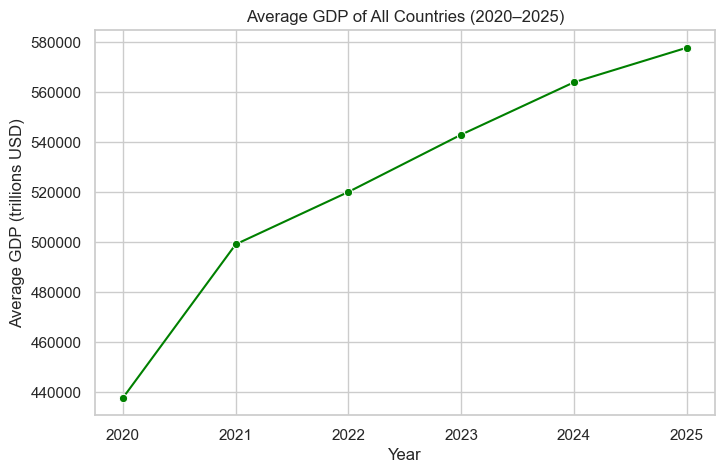

In [16]:
avg_gdp = df.drop('Country', axis=1).mean()
avg_gdp = avg_gdp.reset_index()
avg_gdp.columns = ['Year', 'Average_GDP']

print(avg_gdp)

sns.set(style="whitegrid")
plt.figure(figsize=(8,5))
sns.lineplot(data=avg_gdp, x='Year', y='Average_GDP', marker='o', color='green')
plt.title("Average GDP of All Countries (2020–2025)")
plt.xlabel("Year")
plt.ylabel("Average GDP (trillions USD)")
plt.show()

## 4. Growth Rate Analysis

**Calculate the Compound Annual Growth Rate (CAGR) for each country from 2020 to 2025.**

In [17]:
Num_years  = len(df.columns)-1
df['CAGR'] = ((df['2025'] / df['2020']) ** (1/Num_years)) - 1
df['CAGR'] = df['CAGR'] * 100
df_sort_Country = df.sort_values(by='CAGR', ascending=False).head(10)
print(df_sort_Country[['Country', 'CAGR']])

        Country       CAGR
71       Guyana  29.515136
190   Venezuela  16.754626
93   Kyrgyzstan  15.680057
72        Haiti  14.994353
63      Georgia  14.110496
28      Burundi  13.900949
69       Guinea  13.483649
102       Macau  13.209265
7       Armenia  12.955568
106    Maldives  12.417183


**Predict GDP for 2026 using linear regression based on past 6 years.**

Entry Number between 1 - 196 , Showing Top Country 3


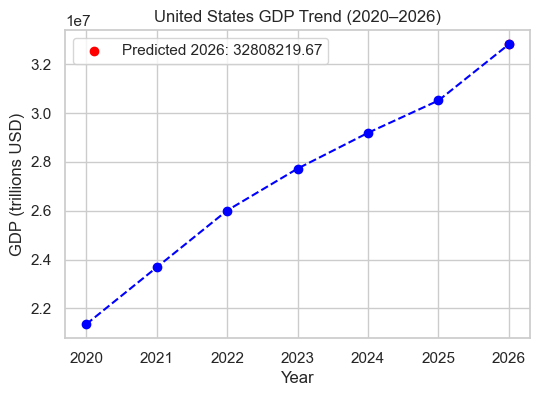

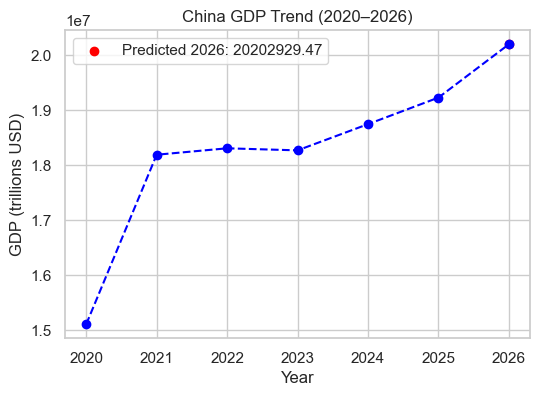

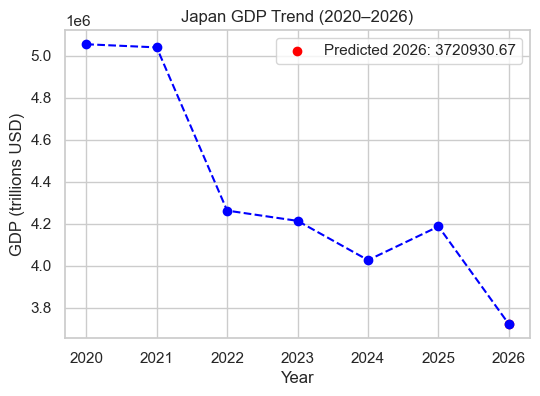

In [18]:
Top_Country = int(input("Entry Number between 1 - 196 , Showing Top Country"))

years = ['2020','2021','2022','2023','2024','2025']

df_temp = df.assign(Total_GDP = df[years].sum(axis=1))
top5_countries = df_temp.sort_values(by='Total_GDP', ascending=False).head(Top_Country)


X = np.array([int(year) for year in years]).reshape(-1,1)


predictions = {}

sns.set(style="whitegrid")

for idx, row in top5_countries.iterrows():
    y = row[years].values
    model = LinearRegression()
    model.fit(X, y)
    
  
    gdp_2026 = model.predict(np.array([[2026]]))[0]
    predictions[row['Country']] = gdp_2026
    
  
    plt.figure(figsize=(6,4))
    
    
    all_years = [int(y) for y in years] + [2026]
    gdp_values = list(y) + [gdp_2026]
    
   
    plt.plot(all_years, gdp_values, marker='o', linestyle='--', color='blue')
    
   
    plt.scatter(2026, gdp_2026, color='red', label=f"Predicted 2026: {gdp_2026:.2f}")
    
    plt.title(f"{row['Country']} GDP Trend (2020–2026)")
    plt.xlabel("Year")
    plt.ylabel("GDP (trillions USD)")
    plt.xticks(all_years)
    plt.legend()
    plt.show()

**Identify countries whose GDP is growing faster than the global average.**

In [19]:
years = ['2020','2021','2022','2023','2024','2025']
global_avg = df[years].mean()
global_growth = global_avg['2025'] - global_avg['2020']

print("Global GDP Growth (2020–2025):", round(global_growth, 2))


df['GDP_Growth'] = df['2025'] - df['2020']

faster_countries = df[df['GDP_Growth'] > global_growth]
print("\n Countries whose GDP grew faster than global average:\n")
print(faster_countries[['Country','GDP_Growth']])


Global GDP Growth (2020–2025): 139854.9

 Countries whose GDP grew faster than global average:

                  Country  GDP_Growth
6               Argentina      298315
9               Australia      409068
17                Belgium      155595
24                 Brazil      649866
32                 Canada      569656
36                  China     4128348
37               Colombia      157418
60                 France      565486
64                Germany      807815
77                  India     1512165
78              Indonesia      370688
79                   Iran      145485
81                Ireland      162635
82                 Israel      172590
83                  Italy      516899
112                Mexico      571575
123           Netherlands      340197
138                Poland      374030
142               Romania      151023
143                Russia      588278
148          Saudi Arabia      349478
153             Singapore      215608
160                 Spain     